# 03 — Relative Difference Scoring (RDS)

**Goal:** Compute the **Relative Difference Score** for each template — the core innovation of the algorithm.

In the previous notebook we saw that raw reward rates can be misleading because eligibility is confounded with user quality. RDS fixes this by comparing each template against its *actual competition* in every event.

This notebook answers:
- What is a counterfactual baseline?
- How does RDS remove confounding?
- Does the template ranking change after applying RDS?

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from src.data_loader import iter_parquet_chunks
from src.scoring.difference_score import (
    compute_template_reward_rates,
    compute_counterfactual_baseline,
    compute_relative_difference_scores_fast,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

CHUNK_SIZE = 1_000_000
INTERMEDIATE_DIR = os.path.join("..", "data", "intermediate")

print("Ready!")

Ready!


---
## 1. Load Reward Rates from Notebook 02 (Full Data)

We load the reward rates computed from all ~88M training rows in notebook 02.

In [2]:
with open(os.path.join(INTERMEDIATE_DIR, "02_results.json")) as f:
    prev = json.load(f)

reward_rates = prev["reward_rates"]
counts = {k: int(v) for k, v in prev["counts"].items()}
total_rows = prev["total_rows"]

print(f"Loaded reward rates from full data ({total_rows:,} rows)")
for t in sorted(reward_rates):
    print(f"  Template {t}: reward_rate = {reward_rates[t]:.4f}, count = {counts[t]:,}")

Loaded reward rates from full data (87,665,839 rows)
  Template A: reward_rate = 0.2690, count = 3,472,696
  Template B: reward_rate = 0.1285, count = 9,059,625
  Template C: reward_rate = 0.4123, count = 2,523,858
  Template D: reward_rate = 0.1310, count = 9,054,749
  Template E: reward_rate = 0.1295, count = 9,060,589
  Template F: reward_rate = 0.1289, count = 9,057,400
  Template G: reward_rate = 0.1316, count = 9,058,068
  Template H: reward_rate = 0.1287, count = 9,124,283
  Template J: reward_rate = 0.1304, count = 9,062,686
  Template K: reward_rate = 0.1316, count = 9,129,646
  Template L: reward_rate = 0.1317, count = 9,062,239


---
## 2. The Counterfactual Baseline — Concept

For **each notification event** we ask: *"If Duolingo had chosen a template at random from the eligible set, what reward would we expect?"*

$$\text{baseline}(\text{event}) = \frac{1}{|\text{eligible}|} \sum_{t \in \text{eligible}} \text{reward\_rate}(t)$$

This baseline is **different for every event** because eligible sets vary. That's the key: we compare each template against *its actual competition*, not against a fixed global average.

In [3]:
# Worked example with a single event (load a tiny sample just for illustration)
import src.data_loader as _dl
_dl.USE_FULL_DATA = False
from src.data_loader import load_sample

sample_df = load_sample(n_rows=1000, split="train")
example_row = sample_df.iloc[0]
eligible = example_row["eligible_templates"]
if isinstance(eligible, str):
    import ast
    eligible = ast.literal_eval(eligible)

print(f"Event 0:")
print(f"  Selected template: {example_row['selected_template']}")
print(f"  Reward (engaged?):  {example_row['session_end_completed']}")
print(f"  Eligible templates: {eligible}")
print()

# Show reward rate of each eligible template (from FULL data)
print(f"  Reward rates of eligible templates (from full {total_rows:,}-row dataset):")
for t in eligible:
    print(f"    {t}: {reward_rates.get(t, 0):.4f}")

# Compute baseline
bl = compute_counterfactual_baseline(eligible, reward_rates)
print(f"\n  Counterfactual baseline = average of above = {bl:.4f}")

# Compute diff
diff = example_row["session_end_completed"] - bl
print(f"  Diff = reward ({example_row['session_end_completed']}) - baseline ({bl:.4f}) = {diff:+.4f}")
if diff > 0:
    print(f"  → This event performed BETTER than expected under random selection.")
else:
    print(f"  → This event performed WORSE than expected under random selection.")

[data_loader] Found 3 parquet files for 'train' split
[data_loader] === SAMPLE MODE ===
[data_loader] Loading 1,000 rows from 3 file(s)...
  Read part-00000-9b4bba6b-feac-44b1-a155-17c796835cca-c000.snappy.parquet: 1,980,100 rows so far
[data_loader] Raw data loaded: 1,000 rows in 4.7s
[data_loader] Memory (raw): 0.3 MB
[data_loader] Post-processing columns (parsing history & templates)...
[postprocess] Processing 1,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000 done in 1.1s | Total: 1,000/1,000 (100%) | ETA: 0s
[postprocess] All 1,000 rows processed in 1.1s
[data_loader] Post-processing done in 1.1s
[data_loader] ✓ Final: 1,000 rows loaded in 5.8s total
[data_loader] Columns: ['datetime', 'ui_language', 'eligible_templates', 'history', 'selected_template', 'session_end_completed']
[data_loader] Memory (final): 0.4 MB
Event 0:
  Selected template: B
  Reward (engaged?):  0
  Eligible templates: ['G', 'E', 'B', 'A', 'K', 'H', 'J', 'L', 'F', 'D']

  Reward rates of eli

---
## 3. Computing Relative Difference Scores

The RDS for template *a* is the **average diff** across all events where template *a* was selected:

$$\text{RDS}(a) = \frac{1}{n_a} \sum_{\text{events where } a \text{ was sent}} \Big( \text{reward} - \text{baseline}(\text{event}) \Big)$$

- **Positive RDS** → template consistently outperforms its peers  
- **Negative RDS** → template consistently underperforms  
- **Near zero** → about average

In [4]:
import time

# Compute RDS on FULL training data via chunks
# Only need eligible_templates + selected_template + reward → skip history parsing
diff_sum = defaultdict(float)
diff_count = defaultdict(int)

t0 = time.time()
for chunk in iter_parquet_chunks("train", CHUNK_SIZE,
                                  columns=["eligible_templates", "selected_template",
                                           "session_end_completed"],
                                  parse_eligible=True, parse_hist=False):
    baselines = chunk["eligible_templates"].apply(
        lambda elig: compute_counterfactual_baseline(elig, reward_rates)
    )
    diffs = chunk["session_end_completed"].values - baselines.values

    for tmpl in chunk["selected_template"].unique():
        mask = chunk["selected_template"].values == tmpl
        diff_sum[tmpl] += diffs[mask].sum()
        diff_count[tmpl] += mask.sum()
    del chunk, baselines, diffs

rds_scores = {t: diff_sum[t] / diff_count[t] for t in diff_sum}
elapsed = time.time() - t0

print(f"\n✅ RDS computed from {total_rows:,} rows in {elapsed:.0f}s\n")
for t in sorted(rds_scores):
    print(f"  Template {t}: RDS = {rds_scores[t]:+.6f} (from {diff_count[t]:,} events)")

[data_loader] Found 3 parquet files for 'train' split
[iter_chunks] File 1/3: part-00000-9b4bba6b-feac-44b1-a155-17c796835cca-c000.snappy.parquet (25,613,243 rows, 13 row groups)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 1,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 2,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 3,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 4,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 5,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 6,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 7,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 8,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 9,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 10,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 11,000,000)
[iter_chunks] Yielding chun

---
## 4. Raw Reward Rate vs RDS — Ranking Comparison

This is the most important chart: does the ranking change when we switch from raw rates to RDS?

In [5]:
# Build comparison table
templates = sorted(reward_rates.keys())

comparison = pd.DataFrame({
    "template": templates,
    "raw_rate": [reward_rates[t] for t in templates],
    "rds": [rds_scores[t] for t in templates],
    "count": [counts[t] for t in templates],
})

comparison["raw_rank"] = comparison["raw_rate"].rank(ascending=False).astype(int)
comparison["rds_rank"] = comparison["rds"].rank(ascending=False).astype(int)
comparison["rank_change"] = comparison["raw_rank"] - comparison["rds_rank"]

print("Raw Reward Rate vs Relative Difference Score:\n")
print(comparison.sort_values("rds_rank")[
    ["template", "raw_rate", "raw_rank", "rds", "rds_rank", "rank_change", "count"]
].to_string(index=False))

movers = comparison[comparison["rank_change"] != 0]
if len(movers) > 0:
    print(f"\n{len(movers)} template(s) changed rank after applying RDS!")
else:
    print(f"\nNo rank changes — raw rates and RDS agree on this sample.")

Raw Reward Rate vs Relative Difference Score:

template  raw_rate  raw_rank           rds  rds_rank  rank_change   count
       A  0.268958         2  1.244477e-01         1            1 3472696
       C  0.412298         1 -1.734790e-17         2           -1 2523858
       L  0.131680         3 -3.776154e-03         3            0 9062239
       G  0.131586         4 -3.868039e-03         4            0 9058068
       K  0.131572         5 -4.072427e-03         5            0 9129646
       D  0.130969         6 -4.490293e-03         6            0 9054749
       J  0.130362         7 -5.097204e-03         7            0 9062686
       E  0.129533         8 -5.923821e-03         8            0 9060589
       F  0.128914         9 -6.545855e-03         9            0 9057400
       H  0.128724        10 -6.920274e-03        10            0 9124283
       B  0.128534        11 -6.922066e-03        11            0 9059625

2 template(s) changed rank after applying RDS!


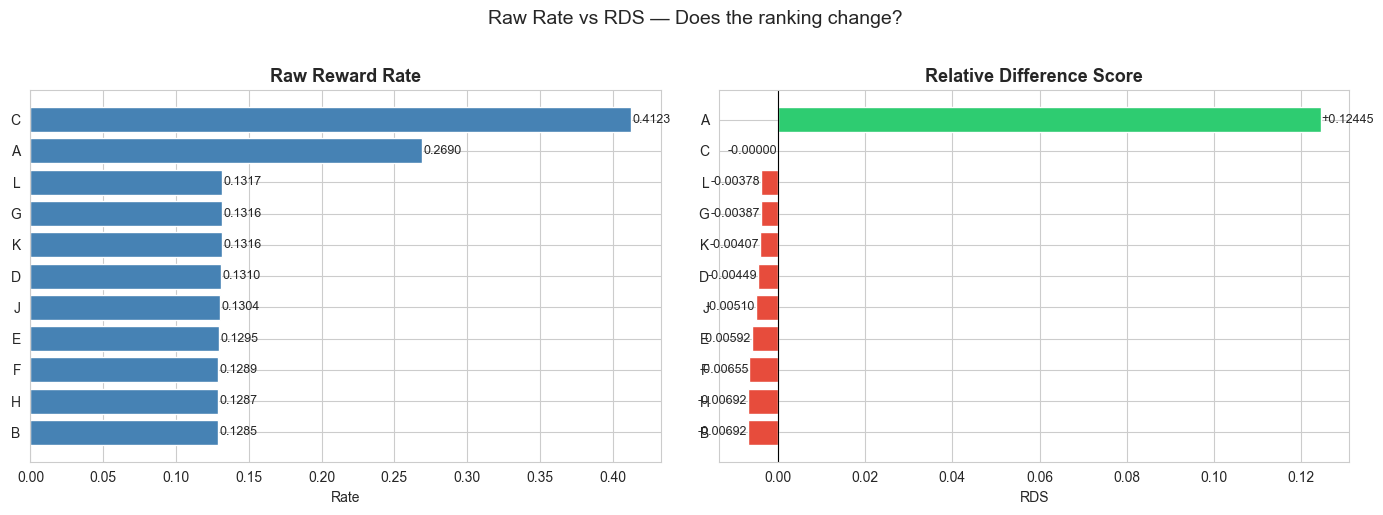

In [6]:
# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw reward rates
raw_sorted = comparison.sort_values("raw_rate", ascending=True)
axes[0].barh(raw_sorted["template"], raw_sorted["raw_rate"],
             color="steelblue", edgecolor="white")
axes[0].set_title("Raw Reward Rate", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Rate")
for i, (_, row) in enumerate(raw_sorted.iterrows()):
    axes[0].text(row["raw_rate"] + 0.001, i, f"{row['raw_rate']:.4f}",
                va="center", fontsize=9)

# Right: RDS
rds_sorted = comparison.sort_values("rds", ascending=True)
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in rds_sorted["rds"]]
axes[1].barh(rds_sorted["template"], rds_sorted["rds"],
             color=colors, edgecolor="white")
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_title("Relative Difference Score", fontsize=13, fontweight="bold")
axes[1].set_xlabel("RDS")
for i, (_, row) in enumerate(rds_sorted.iterrows()):
    offset = 0.0002 if row["rds"] >= 0 else -0.0002
    ha = "left" if row["rds"] >= 0 else "right"
    axes[1].text(row["rds"] + offset, i, f"{row['rds']:+.5f}",
                va="center", ha=ha, fontsize=9)

plt.suptitle("Raw Rate vs RDS — Does the ranking change?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Interpreting the Scores

The RDS values are **small numbers** — typically between -0.01 and +0.01. This is expected:

- A template that's 1% better than its peers has RDS ≈ +0.01
- Even a 1-2% lift matters enormously at Duolingo's scale (hundreds of millions of notifications)

The sign tells the story:
- **Positive RDS:** This template genuinely helps users engage, even after adjusting for who sees it
- **Negative RDS:** This template underperforms regardless of user quality
- **Near zero:** Average — not particularly good or bad

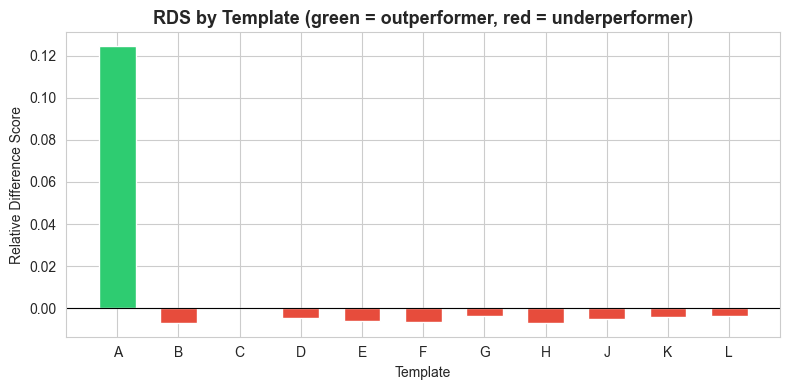

Best template by RDS:  A (+0.124448)
Worst template by RDS: B (-0.006922)
Spread: 0.131370


In [7]:
# Distribution of RDS values
fig, ax = plt.subplots(figsize=(8, 4))

rds_values = [rds_scores[t] for t in templates]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in rds_values]

ax.bar(templates, rds_values, color=colors, edgecolor="white", width=0.6)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("RDS by Template (green = outperformer, red = underperformer)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Template")
ax.set_ylabel("Relative Difference Score")

plt.tight_layout()
plt.show()

best = max(rds_scores, key=rds_scores.get)
worst = min(rds_scores, key=rds_scores.get)
print(f"Best template by RDS:  {best} ({rds_scores[best]:+.6f})")
print(f"Worst template by RDS: {worst} ({rds_scores[worst]:+.6f})")
print(f"Spread: {rds_scores[best] - rds_scores[worst]:.6f}")

---
## 6. Summary

| Concept | What it does |
|---------|-------------|
| **Counterfactual baseline** | For each event, average reward rate of all eligible templates |
| **Diff** | Observed reward minus counterfactual baseline |
| **RDS** | Average diff per template — measures genuine quality |

**Key takeaway:** RDS removes the confounding effect of user quality. A template with high raw reward rate but low/negative RDS was benefiting from being shown to active users — it's not actually a good template.

**Problem remaining:** Templates with few observations have noisy RDS values. We need to regularize.

**Next notebook:** `04_bayesian_smoothing_and_recency.ipynb` — smooth the scores with Bayesian shrinkage and add recency penalties.

In [8]:
# Save intermediate results for next notebooks
results_03 = {
    "reward_rates": reward_rates,
    "counts": counts,
    "rds_scores": rds_scores,
    "total_rows": total_rows,
}

save_path = os.path.join(INTERMEDIATE_DIR, "03_results.json")
with open(save_path, "w") as f:
    json.dump(results_03, f, indent=2)

print(f"✅ Saved to {save_path}")

✅ Saved to ../data/intermediate/03_results.json
